In [3]:
!pip install econml

In [4]:
!pip install econml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("/Users/ameypatil/Desktop/Tata Power/data/2024 data/with socio/autumn_2024.csv")

df = df.dropna().reset_index(drop=True)

# =====================================================
# Outcome
# =====================================================

Y = df["wdLoad"].values

# =====================================================
# Treatments
# Temperature and Relative Humidity
# =====================================================

T = df[
    [
        "temp",
        "rh"
    ]
].values

# =====================================================
# Confounders / Adjustment Variables
# =====================================================

X = df[
    [
        "hour",
        "weekend",
        "holiday",
        "festival",
        "office_hours"
    ]
].values

# =====================================================
# Causal Forest
# =====================================================

model = CausalForestDML(

    model_y=RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    model_t=MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )
    ),

    n_estimators=500,

    min_samples_leaf=10,

    random_state=42
)

# =====================================================
# Train Model
# =====================================================

model.fit(
    Y,
    T,
    X=X
)

# =====================================================
# Conditional Marginal Effects
# =====================================================

effects = model.const_marginal_effect(X)

temp_effect = effects[:, 0]
rh_effect = effects[:, 1]

# =====================================================
# Average Marginal Effect
# =====================================================

ate_temp = np.mean(temp_effect)
ate_rh = np.mean(rh_effect)

print("\n========== AUTUMN WEATHER EFFECTS ==========")

print("Average Marginal Effect (Temperature → Load):",
      ate_temp)

print("Average Marginal Effect (Humidity → Load):",
      ate_rh)

# =====================================================
# Treatment Statistics
# =====================================================

print("\n========== TREATMENT STATISTICS ==========")

print("Temperature range:",
      df["temp"].min(),
      "to",
      df["temp"].max())

print("Humidity range:",
      df["rh"].min(),
      "to",
      df["rh"].max())

print("\nOffice Hours distribution:")
print(df["office_hours"].value_counts())


========== AUTUMN WEATHER EFFECTS ==========
Average Marginal Effect (Temperature → Load): 7.598424949372716
Average Marginal Effect (Humidity → Load): 0.8473596325098269

========== TREATMENT STATISTICS ==========
Temperature range: 19.2 to 37.3
Humidity range: 26.55 to 96.36666667

Office Hours distribution:
office_hours
0    3660
1    2196
Name: count, dtype: int64


In [5]:
# =====================================================
# SOCIO-ECONOMIC / CALENDAR CAUSAL ANALYSIS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor


# =====================================================
# FUNCTION: BINARY TREATMENT EFFECT
# =====================================================

def estimate_binary_treatment(df, treatment, controls):

    # -------------------------------------------------
    # Outcome
    # -------------------------------------------------

    Y = df["wdLoad"].values

    # -------------------------------------------------
    # Binary Treatment
    # -------------------------------------------------

    T = df[treatment].values

    # -------------------------------------------------
    # Adjustment Variables
    # -------------------------------------------------

    X = df[controls].values

    # -------------------------------------------------
    # Causal Forest
    # -------------------------------------------------

    model = CausalForestDML(

        model_y=RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ),

        model_t=RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ),

        n_estimators=500,

        min_samples_leaf=10,

        random_state=42
    )

    # -------------------------------------------------
    # Train
    # -------------------------------------------------

    model.fit(
        Y,
        T,
        X=X
    )

    # -------------------------------------------------
    # Individual Treatment Effects
    # 0 → 1
    # -------------------------------------------------

    effects = model.effect(
        X,
        T0=0,
        T1=1
    )

    # -------------------------------------------------
    # Average Treatment Effect
    # -------------------------------------------------

    ate = np.mean(effects)

    # -------------------------------------------------
    # 95% Confidence Interval
    # -------------------------------------------------

    inference = model.ate_inference(
        X,
        T0=0,
        T1=1
    )

    ci = inference.conf_int_mean()

    return model, effects, ate, ci


# =====================================================
# TREATMENT 1: WEEKEND
# =====================================================

weekend_model, weekend_effect, weekend_ate, weekend_ci = \
    estimate_binary_treatment(
        df,
        "weekend",
        [
            "temp",
            "rh",
            "hour",
            "holiday",
            "festival",
            "office_hours"
        ]
    )


# =====================================================
# TREATMENT 2: HOLIDAY
# =====================================================

holiday_model, holiday_effect, holiday_ate, holiday_ci = \
    estimate_binary_treatment(
        df,
        "holiday",
        [
            "temp",
            "rh",
            "hour",
            "weekend",
            "festival",
            "office_hours"
        ]
    )


# =====================================================
# TREATMENT 3: FESTIVAL
# =====================================================

festival_model, festival_effect, festival_ate, festival_ci = \
    estimate_binary_treatment(
        df,
        "festival",
        [
            "temp",
            "rh",
            "hour",
            "weekend",
            "holiday",
            "office_hours"
        ]
    )


# =====================================================
# TREATMENT 4: OFFICE HOURS
# =====================================================
# NOTE:
# 'hour' is intentionally excluded because office_hours
# is strongly related to time of day.
# =====================================================

office_model, office_effect, office_ate, office_ci = \
    estimate_binary_treatment(
        df,
        "office_hours",
        [
            "temp",
            "rh",
            "weekend",
            "holiday",
            "festival"
        ]
    )


# =====================================================
# RESULTS
# =====================================================

print("\n==============================================")
print("SOCIO-ECONOMIC / CALENDAR CAUSAL EFFECTS")
print("==============================================")

print("\nWeekend → Load")
print("ATE:", weekend_ate)
print("95% CI:", weekend_ci)

print("\nHoliday → Load")
print("ATE:", holiday_ate)
print("95% CI:", holiday_ci)

print("\nFestival → Load")
print("ATE:", festival_ate)
print("95% CI:", festival_ci)

print("\nOffice Hours → Load")
print("ATE:", office_ate)
print("95% CI:", office_ci)


# =====================================================
# TREATMENT COUNTS
# =====================================================

print("\n==============================================")
print("TREATMENT COUNTS")
print("==============================================")

for treatment in [
    "weekend",
    "holiday",
    "festival",
    "office_hours"
]:

    print("\n", treatment)
    print(df[treatment].value_counts().sort_index())

    print(
        "Treatment rate:",
        df[treatment].mean()
    )


# =====================================================
# FINAL RESULTS TABLE
# =====================================================

results = pd.DataFrame({

    "Treatment": [
        "Weekend",
        "Holiday",
        "Festival",
        "Office Hours"
    ],

    "ATE": [
        weekend_ate,
        holiday_ate,
        festival_ate,
        office_ate
    ],

    "CI Lower": [
        weekend_ci[0],
        holiday_ci[0],
        festival_ci[0],
        office_ci[0]
    ],

    "CI Upper": [
        weekend_ci[1],
        holiday_ci[1],
        festival_ci[1],
        office_ci[1]
    ]

})


print("\n==============================================")
print("FINAL SOCIO-ECONOMIC ATE TABLE")
print("==============================================")

display(results)

# =====================================================
# COMBINATION / JOINT-STATE AUDIT
# =====================================================

state_cols = ["weekend", "holiday", "festival", "office_hours"]

state_counts = (
    df.groupby(state_cols)
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

state_counts["percentage"] = (
    state_counts["count"] / len(df) * 100
)

print("==============================================")
print("OBSERVED CALENDAR / ACTIVITY COMBINATIONS")
print("==============================================")

display(state_counts)


SOCIO-ECONOMIC / CALENDAR CAUSAL EFFECTS

Weekend → Load
ATE: -59.527163001914225
95% CI: (np.float64(-73.55557906492419), np.float64(-45.49874693890426))

Holiday → Load
ATE: -24.650612768289857
95% CI: (np.float64(-46.81450118990449), np.float64(-2.4867243466752313))

Festival → Load
ATE: 19.97348908109397
95% CI: (np.float64(-16.00641469936981), np.float64(55.953392861557745))

Office Hours → Load
ATE: 65.71834923486115
95% CI: (np.float64(6.884594849441697), np.float64(124.55210362028056))

TREATMENT COUNTS

 weekend
weekend
0    4224
1    1632
Name: count, dtype: int64
Treatment rate: 0.2786885245901639

 holiday
holiday
0    4704
1    1152
Name: count, dtype: int64
Treatment rate: 0.19672131147540983

 festival
festival
0    5280
1     576
Name: count, dtype: int64
Treatment rate: 0.09836065573770492

 office_hours
office_hours
0    3660
1    2196
Name: count, dtype: int64
Treatment rate: 0.375

FINAL SOCIO-ECONOMIC ATE TABLE


,Treatment,ATE,CI Lower,CI Upper
0,Weekend,-59.527163,-73.555579,-45.498747
1,Holiday,-24.650613,-46.814501,-2.486724
2,Festival,19.973489,-16.006415,55.953393
3,Office Hours,65.718349,6.884595,124.552104


OBSERVED CALENDAR / ACTIVITY COMBINATIONS


,weekend,holiday,festival,office_hours,count,percentage
0,0,0,0,0,2160,36.885246
1,0,0,0,1,1296,22.131148
6,1,0,0,0,780,13.319672
7,1,0,0,1,468,7.991803
4,0,1,1,0,300,5.122951
2,0,1,0,0,180,3.073770
5,0,1,1,1,180,3.073770
8,1,1,0,0,180,3.073770
3,0,1,0,1,108,1.844262
9,1,1,0,1,108,1.844262


In [6]:
# =====================================================
# CREATE JOINT CALENDAR / ACTIVITY STATE
# =====================================================

df["calendar_state"] = (
    "W" + df["weekend"].astype(str) +
    "_H" + df["holiday"].astype(str) +
    "_F" + df["festival"].astype(str) +
    "_O" + df["office_hours"].astype(str)
)

state_summary = (
    df.groupby("calendar_state")["wdLoad"]
      .agg(["count", "mean", "std"])
      .reset_index()
      .sort_values("count", ascending=False)
)

state_summary["percentage"] = (
    state_summary["count"] / len(df) * 100
)

print("==============================================")
print("JOINT CALENDAR / ACTIVITY STATE SUMMARY")
print("==============================================")

display(state_summary)

# =====================================================
# LABEL THE JOINT STATES FOR EASY INTERPRETATION
# =====================================================

state_labels = {
    "W0_H0_F0_O0": "Normal",
    "W0_H0_F0_O1": "Office Hours",
    "W1_H0_F0_O0": "Weekend",
    "W1_H0_F0_O1": "Weekend + Office Hours",
    "W0_H1_F0_O0": "Holiday",
    "W0_H1_F0_O1": "Holiday + Office Hours",
    "W0_H1_F1_O0": "Holiday + Festival",
    "W0_H1_F1_O1": "Holiday + Festival + Office Hours",
    "W1_H1_F0_O0": "Weekend + Holiday",
    "W1_H1_F0_O1": "Weekend + Holiday + Office Hours",
    "W1_H1_F1_O0": "Weekend + Holiday + Festival",
    "W1_H1_F1_O1": "Weekend + Holiday + Festival + Office Hours"
}

state_summary["state"] = state_summary["calendar_state"].map(state_labels)

display(
    state_summary[
        ["state", "count", "percentage", "mean", "std"]
    ]
)

JOINT CALENDAR / ACTIVITY STATE SUMMARY


,calendar_state,count,mean,std,percentage
0,W0_H0_F0_O0,2160,376.526615,66.645178,36.885246
1,W0_H0_F0_O1,1296,529.278159,48.841793,22.131148
6,W1_H0_F0_O0,780,348.640142,45.099426,13.319672
7,W1_H0_F0_O1,468,423.904753,44.111927,7.991803
4,W0_H1_F1_O0,300,373.040440,60.252413,5.122951
2,W0_H1_F0_O0,180,377.864071,61.134578,3.073770
5,W0_H1_F1_O1,180,511.402048,27.615575,3.073770
8,W1_H1_F0_O0,180,339.593565,35.251253,3.073770
3,W0_H1_F0_O1,108,505.371813,63.579938,1.844262
9,W1_H1_F0_O1,108,382.273565,20.347637,1.844262


,state,count,percentage,mean,std
0,Normal,2160,36.885246,376.526615,66.645178
1,Office Hours,1296,22.131148,529.278159,48.841793
6,Weekend,780,13.319672,348.640142,45.099426
7,Weekend + Office Hours,468,7.991803,423.904753,44.111927
4,Holiday + Festival,300,5.122951,373.040440,60.252413
2,Holiday,180,3.073770,377.864071,61.134578
5,Holiday + Festival + Office Hours,180,3.073770,511.402048,27.615575
8,Weekend + Holiday,180,3.073770,339.593565,35.251253
3,Holiday + Office Hours,108,1.844262,505.371813,63.579938
9,Weekend + Holiday + Office Hours,108,1.844262,382.273565,20.347637


In [7]:
# =====================================================
# OFFICE HOURS TREATMENT SUPPORT BY HOUR
# =====================================================

support_check = (
    df.groupby("hour")["office_hours"]
      .agg(
          total="count",
          treated="sum",
          untreated=lambda x: (x == 0).sum()
      )
      .reset_index()
)

support_check["treated_rate"] = (
    support_check["treated"] /
    support_check["total"]
)

display(support_check)

,hour,total,treated,untreated,treated_rate
0,0,244,0,244,0.0
1,1,244,0,244,0.0
2,2,244,0,244,0.0
3,3,244,0,244,0.0
4,4,244,0,244,0.0
5,5,244,0,244,0.0
6,6,244,0,244,0.0
7,7,244,0,244,0.0
8,8,244,0,244,0.0
9,9,244,244,0,1.0


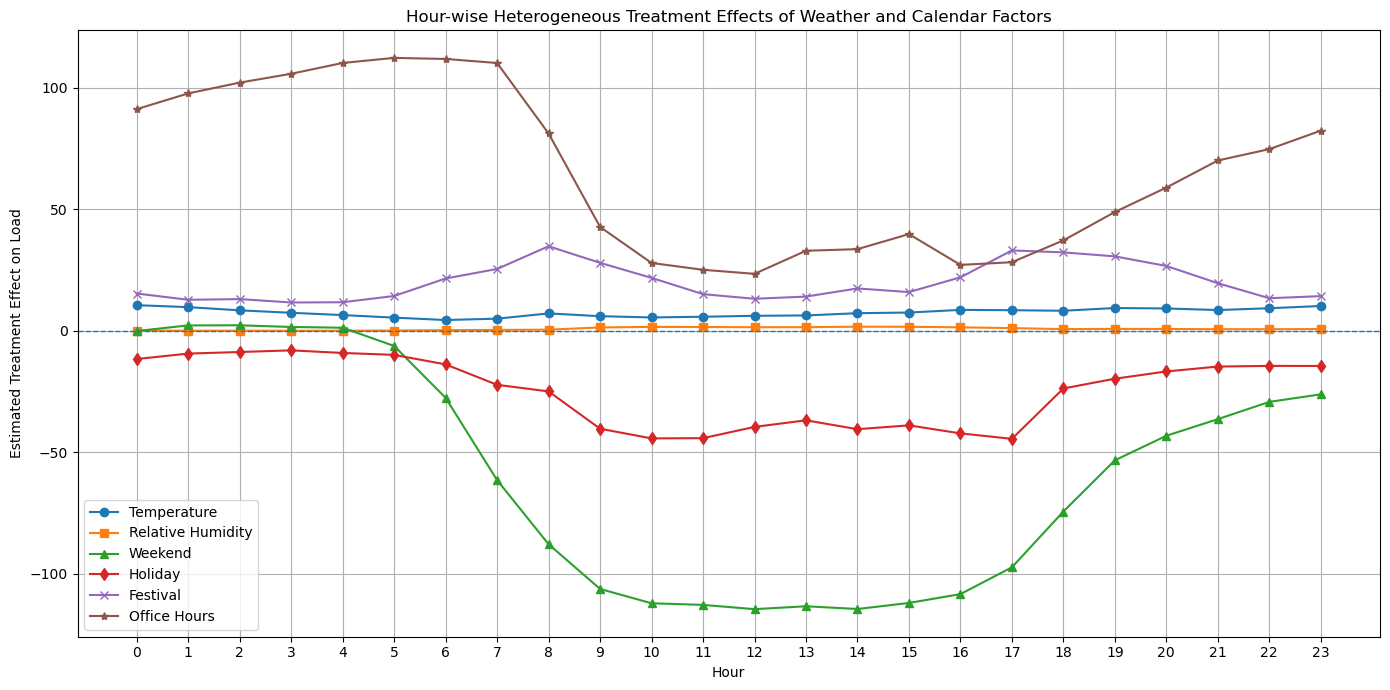

In [8]:
# =====================================================
# HOUR-WISE HETEROGENEOUS TREATMENT EFFECTS
# =====================================================

plot_df = pd.DataFrame({

    "hour": df["hour"],

    # Weather treatment effects
    "Temperature": temp_effect,
    "RH": rh_effect,

    # Socio-economic / calendar treatment effects
    "Weekend": weekend_effect,
    "Holiday": holiday_effect,
    "Festival": festival_effect,
    "Office Hours": office_effect

})


# =====================================================
# CALCULATE AVERAGE EFFECT FOR EACH HOUR
# =====================================================

hour_effect = (
    plot_df
    .groupby("hour")
    .mean()
    .reset_index()
)


# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(14, 7))


# -----------------------------------------------------
# WEATHER EFFECTS
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Temperature"],
    marker="o",
    label="Temperature"
)

plt.plot(
    hour_effect["hour"],
    hour_effect["RH"],
    marker="s",
    label="Relative Humidity"
)


# -----------------------------------------------------
# CALENDAR / HUMAN ACTIVITY EFFECTS
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Weekend"],
    marker="^",
    label="Weekend"
)

plt.plot(
    hour_effect["hour"],
    hour_effect["Holiday"],
    marker="d",
    label="Holiday"
)

plt.plot(
    hour_effect["hour"],
    hour_effect["Festival"],
    marker="x",
    label="Festival"
)

plt.plot(
    hour_effect["hour"],
    hour_effect["Office Hours"],
    marker="*",
    label="Office Hours"
)


# =====================================================
# ZERO REFERENCE LINE
# =====================================================

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)


# =====================================================
# LABELS AND TITLE
# =====================================================

plt.xlabel("Hour")

plt.ylabel(
    "Estimated Treatment Effect on Load"
)

plt.title(
    "Hour-wise Heterogeneous Treatment Effects of Weather and Calendar Factors"
)

plt.xticks(range(24))

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

In [9]:
# ============================================================
# XAI ANALYSIS USING XGBOOST + SHAP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap

# =====================================================
# Load Dataset (added to ensure 'df' is defined)
# =====================================================
# Debugging: List files in current directory to check for 'summer_2024 (1).csv'
!ls -l
df = pd.read_csv("autumn_2024 (1).csv")
df = df.dropna().reset_index(drop=True)

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

# Features used for prediction
features = [
    "temp",
    "rh",
    "hour",
    "weekend",
    "holiday",
    "festival",
    "office_hours"
]

X_xai = df[features].copy()
y_xai = df["wdLoad"].copy()

# ------------------------------------------------------------
# 2. Train XGBoost model
# ------------------------------------------------------------

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_xai, y_xai)

# Predictions
xai_predictions = xgb_model.predict(X_xai)

print("XGBoost XAI model trained successfully.")
print("Features used:", features)


total 14760
-rw-r--r--  1 ameypatil  staff  2484291 Sep  9 23:19 Copy_of_socioMonsoon_v2.ipynb
-rw-r--r--  1 ameypatil  staff   185104 Jul 19 10:43 WhatsApp Image 2026-07-16 at 00.20.01.jpeg
-rw-r--r--  1 ameypatil  staff   187279 Jul 19 10:43 WhatsApp Image 2026-07-16 at 00.20.16.jpeg
-rw-r--r--  1 ameypatil  staff   157861 Sep  9 19:57 autumnsocio.ipynb
-rw-r--r--  1 ameypatil  staff  2511568 Sep  9 23:19 autumnsocio_v2.ipynb
-rw-r--r--  1 ameypatil  staff   558808 Sep  9 23:21 socioSummer_with_LLM_v2.ipynb
-rw-r--r--@ 1 ameypatil  staff   175944 Jul 19 10:37 sociowinter.ipynb
-rw-r--r--  1 ameypatil  staff   632809 Sep  9 23:19 sociowinter_v2.ipynb


FileNotFoundError: [Errno 2] No such file or directory: 'autumn_2024 (1).csv'


Feature Importance:


,Feature,Importance
6,office_hours,0.517569
2,hour,0.219218
3,weekend,0.176927
0,temp,0.039929
4,holiday,0.019726
1,rh,0.014286
5,festival,0.012346


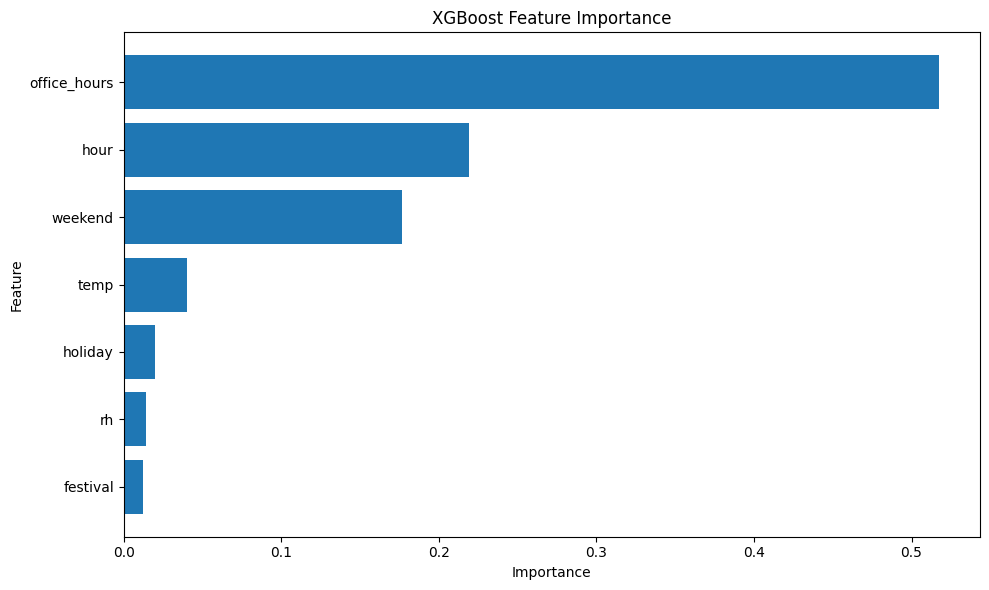

In [ ]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\nFeature Importance:")
display(importance)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SHAP ANALYSIS
# ============================================================

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_xai)

print("SHAP analysis completed.")

SHAP analysis completed.


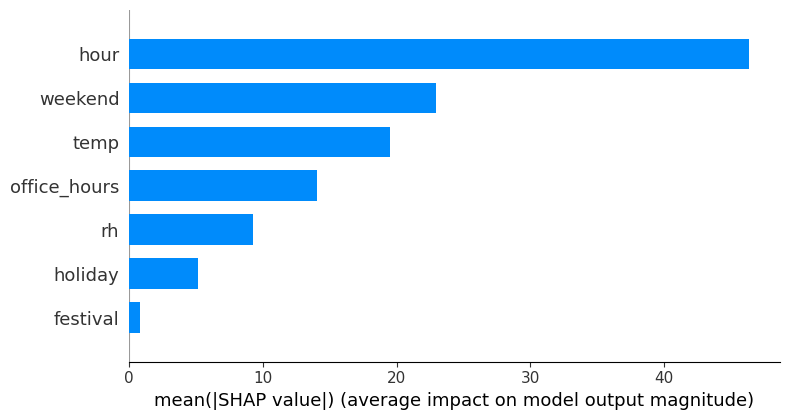

In [ ]:
# ============================================================
# GLOBAL SHAP IMPORTANCE
# ============================================================

shap.summary_plot(
    shap_values,
    X_xai,
    plot_type="bar"
)

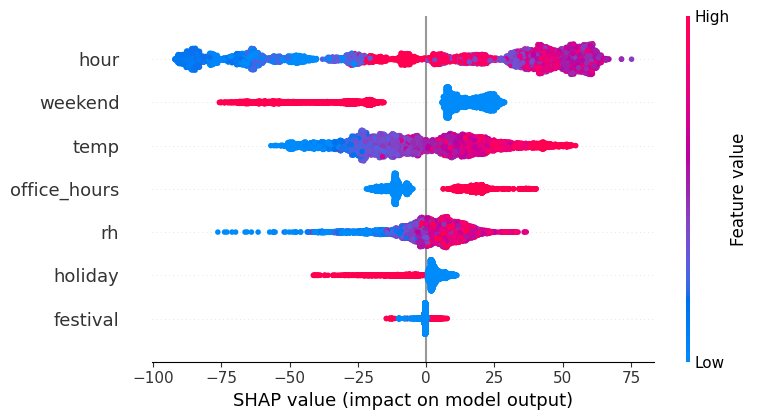

In [ ]:
# ============================================================
# SHAP BEESWARM
# ============================================================

shap.summary_plot(
    shap_values,
    X_xai
)

LIME LOCAL EXPLANATION - AUTUMN 2024
Observation Index : 1678
Actual Load       : 606.14
Predicted Load    : 560.26

Input Features:


,temp,rh,hour,weekend,holiday,festival,office_hours
1678,33.966667,68.133333,11,0,0,0,1



LIME Feature Contributions:
weekend <= 0.00                            68.1187   Positive
temp > 31.77                               39.7167   Positive
0.00 < office_hours <= 1.00                28.4001   Positive
holiday <= 0.00                            18.5313   Positive
5.75 < hour <= 11.50                        7.6141   Positive
59.73 < rh <= 71.70                        -7.0862   Negative
festival <= 0.00                           -1.3548   Negative


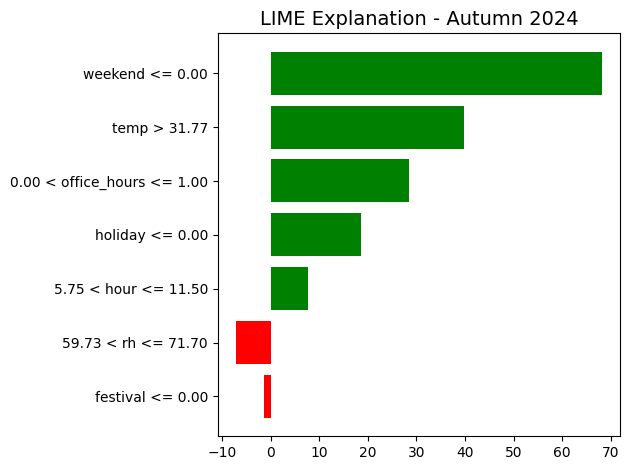

In [ ]:
# ============================================================
# LIME LOCAL EXPLANATION - AUTUMN 2024
# VERSION 1: MATPLOTLIB / BAR GRAPH
# ============================================================
!pip install -q lime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lime.lime_tabular import LimeTabularExplainer
import xgboost as xgb


# ============================================================
# 1. LOAD AUTUMN 2024 DATA
# ============================================================

df = pd.read_csv("autumn_2024 (1).csv")

df = df.dropna().reset_index(drop=True)


# ============================================================
# 2. FEATURES USED FOR XAI
#    SAME FEATURES AS SHAP
# ============================================================

features = [
    "temp",
    "rh",
    "hour",
    "weekend",
    "holiday",
    "festival",
    "office_hours"
]

X_xai = df[features].copy()
y_xai = df["wdLoad"].copy()


# ============================================================
# 3. TRAIN XGBOOST MODEL
# ============================================================

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    X_xai,
    y_xai
)


# ============================================================
# 4. LIME PREDICTION FUNCTION
# ============================================================

def predict_fn(data):

    data_df = pd.DataFrame(
        data,
        columns=features
    )

    return xgb_model.predict(data_df)


# ============================================================
# 5. CREATE LIME EXPLAINER
# ============================================================

lime_explainer = LimeTabularExplainer(
    training_data=X_xai.values,
    feature_names=features,
    mode="regression",
    discretize_continuous=True,
    random_state=42
)


# ============================================================
# 6. SELECT REPRESENTATIVE OBSERVATION
# ============================================================
#
# We use the observation with the highest actual load.
# This provides an interpretable high-load case.
# ============================================================

observation_idx = y_xai.idxmax()

observation = X_xai.loc[
    observation_idx
].values


# ============================================================
# 7. GENERATE LIME EXPLANATION
# ============================================================

explanation = lime_explainer.explain_instance(
    observation,
    predict_fn,
    num_features=7,
    num_samples=5000
)


# ============================================================
# 8. ACTUAL VS PREDICTED LOAD
# ============================================================

actual_load = float(
    y_xai.loc[observation_idx]
)

predicted_load = float(
    xgb_model.predict(
        X_xai.loc[[observation_idx]]
    )[0]
)


print("=" * 70)
print("LIME LOCAL EXPLANATION - AUTUMN 2024")
print("=" * 70)

print("Observation Index :", observation_idx)
print("Actual Load       :", round(actual_load, 2))
print("Predicted Load    :", round(predicted_load, 2))


# ============================================================
# 9. INPUT FEATURES
# ============================================================

print("\nInput Features:")

display(
    X_xai.loc[[observation_idx]]
)


# ============================================================
# 10. LIME CONTRIBUTIONS
# ============================================================

print("\nLIME Feature Contributions:")

for feature_condition, contribution in explanation.as_list():

    direction = (
        "Positive"
        if contribution > 0
        else "Negative"
    )

    print(
        f"{feature_condition:<40}"
        f"{contribution:>10.4f}   "
        f"{direction}"
    )


# ============================================================
# 11. LIME BAR GRAPH
# ============================================================

fig = explanation.as_pyplot_figure()

plt.title(
    "LIME Explanation - Autumn 2024",
    fontsize=14
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# LIME LOCAL EXPLANATION - AUTUMN 2024
# VERSION 2: NATIVE LIME HTML VISUALIZATION
# ============================================================

import numpy as np
import pandas as pd

from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML
import xgboost as xgb


# ============================================================
# 1. LOAD AUTUMN 2024 DATA
# ============================================================

df = pd.read_csv("autumn_2024 (1).csv")

df = df.dropna().reset_index(drop=True)


# ============================================================
# 2. SAME FEATURES USED FOR SHAP
# ============================================================

features = [
    "temp",
    "rh",
    "hour",
    "weekend",
    "holiday",
    "festival",
    "office_hours"
]

X_xai = df[features].copy()
y_xai = df["wdLoad"].copy()


# ============================================================
# 3. TRAIN XGBOOST MODEL
# ============================================================

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    X_xai,
    y_xai
)


# ============================================================
# 4. LIME PREDICTION FUNCTION
# ============================================================

def predict_fn(data):

    data_df = pd.DataFrame(
        data,
        columns=features
    )

    return xgb_model.predict(data_df)


# ============================================================
# 5. CREATE LIME EXPLAINER
# ============================================================

lime_explainer = LimeTabularExplainer(
    training_data=X_xai.values,
    feature_names=features,
    mode="regression",
    discretize_continuous=True,
    random_state=42
)


# ============================================================
# 6. SEARCH FOR A GOOD REPRESENTATIVE OBSERVATION
# ============================================================
#
# We want a real observation for which the LIME explanation
# contains both positive and negative contributions.
#
# This makes the visualization resemble the reference figure.
#
# IMPORTANT:
# We are NOT creating artificial values.
# We are only selecting an observation from the real dataset.
# ============================================================

rng = np.random.RandomState(42)

candidate_indices = rng.choice(
    len(X_xai),
    size=min(300, len(X_xai)),
    replace=False
)

selected_idx = None
selected_explanation = None


for idx in candidate_indices:

    explanation = lime_explainer.explain_instance(
        X_xai.iloc[idx].values,
        predict_fn,
        num_features=2,
        num_samples=5000
    )

    contributions = [
        contribution
        for _, contribution
        in explanation.as_list()
    ]

    has_positive = any(
        contribution > 0
        for contribution in contributions
    )

    has_negative = any(
        contribution < 0
        for contribution in contributions
    )

    if has_positive and has_negative:

        selected_idx = X_xai.index[idx]

        selected_explanation = explanation

        break


# ============================================================
# 7. FALLBACK
# ============================================================
#
# If no sampled observation contains both signs,
# use the highest-load observation.
# ============================================================

if selected_idx is None:

    selected_idx = y_xai.idxmax()

    selected_explanation = (
        lime_explainer.explain_instance(
            X_xai.loc[selected_idx].values,
            predict_fn,
            num_features=2,
            num_samples=5000
        )
    )


# ============================================================
# 8. ACTUAL AND PREDICTED LOAD
# ============================================================

actual_load = float(
    y_xai.loc[selected_idx]
)

predicted_load = float(
    xgb_model.predict(
        X_xai.loc[[selected_idx]]
    )[0]
)


# ============================================================
# 9. DISPLAY INFORMATION
# ============================================================

print("=" * 70)
print("LIME LOCAL EXPLANATION - AUTUMN 2024")
print("=" * 70)

print(
    "Observation Index :",
    selected_idx
)

print(
    "Actual Load       :",
    round(actual_load, 2)
)

print(
    "Predicted Load    :",
    round(predicted_load, 2)
)


print("\nInput Features:")

display(
    X_xai.loc[[selected_idx]]
)


# ============================================================
# 10. DISPLAY CONTRIBUTIONS
# ============================================================

print("\nLIME Feature Contributions:")

for feature_condition, contribution in (
    selected_explanation.as_list()
):

    direction = (
        "Positive"
        if contribution > 0
        else "Negative"
    )

    print(
        f"{feature_condition:<40}"
        f"{contribution:>10.4f}   "
        f"{direction}"
    )


# ============================================================
# 11. NATIVE LIME HTML VISUALIZATION
# ============================================================
#
# This is the important part.
#
# DO NOT use:
#
#     as_pyplot_figure()
#
# Instead use:
#
#     as_html()
#
# ============================================================

lime_html = (
    selected_explanation.as_html()
)

display(
    HTML(lime_html)
)

LIME LOCAL EXPLANATION - AUTUMN 2024
Observation Index : 3649
Actual Load       : 361.38
Predicted Load    : 353.07

Input Features:


,temp,rh,hour,weekend,holiday,festival,office_hours
3649,28.1,69.466667,0,0,0,0,0



LIME Feature Contributions:
hour <= 5.75                              -94.0282   Negative
weekend <= 0.00                            60.4432   Positive


## Summary of Causal Effects

In [ ]:
print("\n========== WEATHER ATEs ==========")
print("Average Marginal Effect (Temperature → Load):", ate_temp)
print("Average Marginal Effect (Humidity → Load):", ate_rh)

print("\n========== SOCIO-ECONOMIC / CALENDAR ATEs ==========")
display(results)

print("\n========== HOUR-WISE HETEROGENEOUS TREATMENT EFFECTS ==========")
display(hour_effect)


========== WEATHER ATEs ==========


NameError: name 'ate_temp' is not defined

Selected Day: 2024-11-17

SINGLE-DAY HOURLY TREATMENT EFFECTS
Date: 2024-11-17


,hour,Temperature,RH,Weekend,Holiday,Festival,Office Hours
0,0,10.896953,0.134595,0.857320,-24.050740,28.923403,39.154074
1,1,10.285432,0.009994,0.122543,-22.097740,31.860096,46.242794
2,2,8.736503,0.080888,0.648461,-20.723594,23.358500,47.639104
3,3,7.126510,0.137893,-0.173270,-19.954833,17.797813,47.754903
4,4,6.233228,0.184555,-0.252050,-20.489906,15.314021,48.300086
5,5,5.500682,0.160377,-2.629838,-21.482113,20.397857,43.596133
6,6,4.292542,0.242013,-22.666435,-22.792999,29.967726,27.642087
7,7,3.389369,0.433050,-58.329329,-33.022886,27.790171,33.056133
8,8,4.077937,0.394812,-85.811466,-36.221774,25.111886,44.156214
9,9,3.447138,0.688413,-102.190025,-47.807902,1.143370,-10.652860


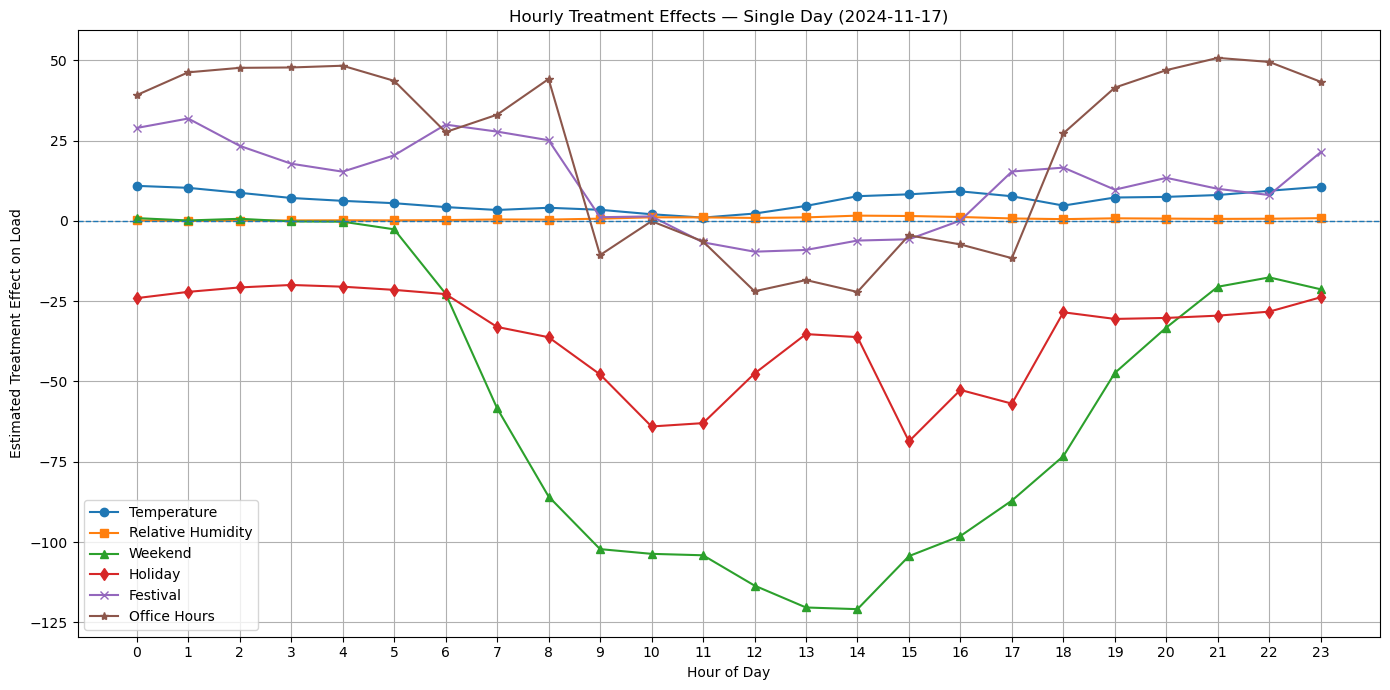

In [10]:
# =====================================================
# SINGLE-DAY HOURLY TREATMENT EFFECTS
# AUTUMN 2024
# =====================================================

# -----------------------------------------------------
# 1. Create date column
# -----------------------------------------------------

df["date"] = pd.to_datetime(df["datetime"]).dt.date


# -----------------------------------------------------
# 2. Select one random day from the actual dataset
# -----------------------------------------------------

selected_date = np.random.choice(
    df["date"].unique()
)

print("Selected Day:", selected_date)


# -----------------------------------------------------
# 3. Create treatment-effect dataframe
# -----------------------------------------------------

single_day_df = pd.DataFrame({

    "date": df["date"],
    "hour": df["hour"],

    "Temperature": temp_effect,
    "RH": rh_effect,

    "Weekend": weekend_effect,
    "Holiday": holiday_effect,
    "Festival": festival_effect,
    "Office Hours": office_effect

})


# -----------------------------------------------------
# 4. Keep ONLY the selected day
# -----------------------------------------------------

single_day_df = single_day_df[
    single_day_df["date"] == selected_date
].copy()


# -----------------------------------------------------
# 5. Calculate hourly treatment effects
# -----------------------------------------------------
#
# If the dataset contains multiple observations within
# an hour (e.g. 15-minute observations), we average
# ONLY those observations within the SAME hour.
#
# We are NOT averaging across different days.
# -----------------------------------------------------

single_day_hour_effect = (
    single_day_df
    .groupby("hour")
    [
        [
            "Temperature",
            "RH",
            "Weekend",
            "Holiday",
            "Festival",
            "Office Hours"
        ]
    ]
    .mean()
    .reset_index()
)


# =====================================================
# 6. DISPLAY THE RESULTS
# =====================================================

print("\n==============================================")
print("SINGLE-DAY HOURLY TREATMENT EFFECTS")
print("==============================================")

print("Date:", selected_date)

display(single_day_hour_effect)


# =====================================================
# 7. PLOT
# =====================================================

plt.figure(figsize=(14, 7))


# -----------------------------------------------------
# WEATHER EFFECTS
# -----------------------------------------------------

plt.plot(
    single_day_hour_effect["hour"],
    single_day_hour_effect["Temperature"],
    marker="o",
    label="Temperature"
)

plt.plot(
    single_day_hour_effect["hour"],
    single_day_hour_effect["RH"],
    marker="s",
    label="Relative Humidity"
)


# -----------------------------------------------------
# CALENDAR / HUMAN ACTIVITY EFFECTS
# -----------------------------------------------------

plt.plot(
    single_day_hour_effect["hour"],
    single_day_hour_effect["Weekend"],
    marker="^",
    label="Weekend"
)

plt.plot(
    single_day_hour_effect["hour"],
    single_day_hour_effect["Holiday"],
    marker="d",
    label="Holiday"
)

plt.plot(
    single_day_hour_effect["hour"],
    single_day_hour_effect["Festival"],
    marker="x",
    label="Festival"
)

plt.plot(
    single_day_hour_effect["hour"],
    single_day_hour_effect["Office Hours"],
    marker="*",
    label="Office Hours"
)


# -----------------------------------------------------
# ZERO REFERENCE
# -----------------------------------------------------

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)


# -----------------------------------------------------
# LABELS
# -----------------------------------------------------

plt.xlabel("Hour of Day")

plt.ylabel(
    "Estimated Treatment Effect on Load"
)

plt.title(
    f"Hourly Treatment Effects — Single Day ({selected_date})"
)

plt.xticks(range(24))

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()